# Market Data Visualization & Fundamental Analysis Audit (Local Dataset)

## 1. Setup & Stock Environment Initialization

In [1]:
"""
Setup environment, import necessary libraries, and initialize local stock dataset.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

# Set global plotting styles for consistent visualization
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Define target ticker symbol and local dataset paths
TICKER = 'AAPL'
DATA_PATH = "../data/datasets/daily_features/s_and_p_500_daily_features.parquet"
EVENT_PATH = "../data/datasets/events/s_and_p_500_events.parquet"

try:
    # Load and preprocess the main dataset
    df_all = pd.read_parquet(DATA_PATH)
    df_all['Date'] = pd.to_datetime(df_all['Date'])
    
    # Apply base filters: remove inactive or corrupted records
    df_all = df_all[(df_all['Market Cap'] > 0) & (df_all['Close'] > 0)]
    
    # Filter specifically for the target ticker and sort chronologically
    df = df_all[df_all['Ticker'] == TICKER].copy()
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Extract basic company information from the most recent record
    latest_data = df.iloc[-1]
    company_name = latest_data.get('Company Name', TICKER)
    sector = latest_data.get('GICS Sector', 'N/A')
    industry = latest_data.get('GICS Sub-Industry', 'N/A')
    currency = 'USD'

    # Print initialization summary
    print(f"=== LOADED DATA FOR: {company_name} ({TICKER}) ===")
    print(f"Sector: {sector} | Industry: {industry}")
    print(f"Total historical records available: {len(df):,}")
    print(f"Latest Point-in-Time Record Date: {latest_data['Date'].strftime('%Y-%m-%d')}")
    
except FileNotFoundError:
    print(f"Dataset not found at '{DATA_PATH}'. Please ensure the path is correct.")

=== LOADED DATA FOR: AAPL (AAPL) ===
Sector: N/A | Industry: N/A
Total historical records available: 2,766
Latest Point-in-Time Record Date: 2025-12-31


## 2. Valuation Multiples & Market Metrics

In [2]:
"""
Extract and calculate valuation multiples from the latest Point-in-Time data.
"""
def fmt_val(val, is_curr=False, is_pct=False, is_int=False, scale_pct=True):
    """
    Format numerical values for standardized display in tables and dataframes.
    
    Args:
        val (float|int|str|None): The raw metric value.
        is_curr (bool): Flag indicating if the value represents currency.
        is_pct (bool): Flag indicating if the value represents a percentage.
        is_int (bool): Flag indicating if the value should be forced to an integer.
        scale_pct (bool): Flag indicating if the percentage should be multiplied by 100.
        
    Returns:
        str: The formatted string representation of the input metric.
    """
    if val is None or pd.isna(val):
        return "N/A"
    try:
        val = float(val)
    except (ValueError, TypeError):
        return str(val)

    if is_int:
        return f"{int(round(val)):,}"
    if is_pct:
        if scale_pct:
            val = val * 100
        return f"{val:.2f}%"
    if is_curr:
        return f"{val:,.2f} {currency}"

    return f"{val:,.2f}"

# Extract essential market valuation metrics from the latest row
mcap = latest_data.get('Market Cap')
ltd = latest_data.get('Long-Term Debt', 0)
cash = latest_data.get('Cash and Equivalents', 0)
revenue = latest_data.get('Revenue')

# Calculate Enterprise Value (EV)
ev = mcap + ltd - cash if pd.notna(mcap) else None

# Calculate custom multiples if base components are available
ps_ratio = mcap / revenue if pd.notna(revenue) and pd.notna(mcap) and revenue != 0 else None
ev_rev = ev / revenue if pd.notna(revenue) and pd.notna(ev) and revenue != 0 else None

# Map raw data to readable descriptions
valuation_data = {
    'Metric': [
        'Current Market Price', 'Market Cap', 'Enterprise Value (EV)',
        'Trailing P/E', 'Price/Book (P/B)', 'Price/Sales (P/S)', 'EV / Revenue'
    ],
    'Value': [
        fmt_val(latest_data.get('Close'), is_curr=True),
        fmt_val(mcap, is_int=True),
        fmt_val(ev, is_int=True),
        fmt_val(latest_data.get('P/E Ratio')),
        fmt_val(latest_data.get('P/B Ratio')),
        fmt_val(ps_ratio),
        fmt_val(ev_rev)
    ]
}

# Generate the styled dataframe
df_valuation = pd.DataFrame(valuation_data)
df_valuation.style.hide(axis="index").set_caption(f"{company_name} - Valuation Multiples").set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('background-color', '#f4f4f4')]},
    {'selector': 'td', 'props': [('padding', '6px 12px')]}
])

Metric,Value
Current Market Price,271.86 USD
Market Cap,"4,298,798,795,791"
Enterprise Value (EV),"4,364,114,795,791"
Trailing P/E,44.35
Price/Book (P/B),69.17
Price/Sales (P/S),16.19
EV / Revenue,16.43


## 3. Financial Health, Profitability & Solvency Ratios

In [3]:
"""
Compile and display key financial health metrics including profitability and solvency based on local features.
"""
# Extract core financial figures
gross_profit = latest_data.get('Gross Profit')
op_income = latest_data.get('Operating Income')
net_income = latest_data.get('Net Income')
equity = latest_data.get('Stockholders Equity')
assets = latest_data.get('Total Assets')
curr_assets = latest_data.get('Current Assets')
curr_liab = latest_data.get('Current Liabilities')
total_debt = latest_data.get('Long-Term Debt')

# Perform ratio calculations safely
gross_margin = gross_profit / revenue if pd.notna(gross_profit) and pd.notna(revenue) and revenue != 0 else None
op_margin = op_income / revenue if pd.notna(op_income) and pd.notna(revenue) and revenue != 0 else None
net_margin = net_income / revenue if pd.notna(net_income) and pd.notna(revenue) and revenue != 0 else None
roe = net_income / equity if pd.notna(net_income) and pd.notna(equity) and equity != 0 else None
roa = net_income / assets if pd.notna(net_income) and pd.notna(assets) and assets != 0 else None
current_ratio = curr_assets / curr_liab if pd.notna(curr_assets) and pd.notna(curr_liab) and curr_liab != 0 else None
debt_to_equity = total_debt / equity if pd.notna(total_debt) and pd.notna(equity) and equity != 0 else None

health_data = {
    'Category': [
        'Profitability', 'Profitability', 'Profitability', 'Profitability', 'Profitability',
        'Solvency & Debt', 'Solvency & Debt', 'Solvency & Debt'
    ],
    'Ratio / Metric': [
        'Gross Margin', 'Operating Margin', 'Profit Margin (Net)',
        'Return on Equity (ROE)', 'Return on Assets (ROA)',
        'Current Ratio', 'Long-Term Debt / Equity', 'Total Cash & Equivalents'
    ],
    'Value': [
        fmt_val(gross_margin, is_pct=True),
        fmt_val(op_margin, is_pct=True),
        fmt_val(net_margin, is_pct=True),
        fmt_val(roe, is_pct=True),
        fmt_val(roa, is_pct=True),
        fmt_val(current_ratio),
        fmt_val(debt_to_equity, is_pct=True),
        fmt_val(cash, is_int=True)
    ]
}

df_health = pd.DataFrame(health_data)
df_health.style.hide(axis="index").set_caption(f"{company_name} - Financial Health & Ratios")

Category,Ratio / Metric,Value
Profitability,Gross Margin,112.15%
Profitability,Operating Margin,75.92%
Profitability,Profit Margin (Net),64.40%
Profitability,Return on Equity (ROE),275.21%
Profitability,Return on Assets (ROA),48.51%
Solvency & Debt,Current Ratio,0.99
Solvency & Debt,Long-Term Debt / Equity,153.32%
Solvency & Debt,Total Cash & Equivalents,"29,965,000,000"


## 4. Income Statement & Cash Flow Trends

In [4]:
"""
Extract historical financial statements and plot revenue, net income, and free cash flow trends.
Assumes the dataset holds Point-in-Time features, using the last available record of each year.
"""
# Extract the last record for each year to get annual figures
annual_df = df.groupby(df['Date'].dt.year)[['Revenue', 'Net Income', 'Operating Cash Flow', 'CapEx']].last().dropna(how='all')

if not annual_df.empty:
    # Compute Free Cash Flow dynamically (Op Cash Flow minus Absolute CapEx to prevent miscalculation)
    annual_df['Free Cash Flow'] = annual_df['Operating Cash Flow'] - annual_df['CapEx'].abs()
    
    # Scale financial amounts to billions for readability
    annual_df = annual_df / 1e9
    
    fig = go.Figure()
    if 'Revenue' in annual_df.columns:
        fig.add_trace(go.Bar(x=annual_df.index, y=annual_df['Revenue'], name='Revenue (Billion)', marker_color='#1f77b4'))
    if 'Net Income' in annual_df.columns:
        fig.add_trace(go.Bar(x=annual_df.index, y=annual_df['Net Income'], name='Net Income (Billion)', marker_color='#2ca02c'))
    if 'Free Cash Flow' in annual_df.columns:
        fig.add_trace(go.Scatter(x=annual_df.index, y=annual_df['Free Cash Flow'], name='Free Cash Flow (Billion)', mode='lines+markers', line=dict(color='#ff7f0e', width=3)))

    fig.update_layout(
        title=f'{TICKER} - Historical Financial Trends (Billions {currency})',
        barmode='group',
        xaxis_title='Fiscal Year',
        yaxis_title=f'Amount (Billions {currency})',
        template='plotly_white',
        height=450
    )
    fig.show()
else:
    print("Financial trend data unavailable in the local dataset.")

## 5. Technical Analysis (Candlestick, Moving Averages, RSI, MACD)

In [5]:
"""
Plot common technical indicators using pre-calculated features from the dataset.
Calculates MACD dynamically from the Close price.
"""
# Extract data for the last 2 years (approximately 504 trading days)
hist = df.tail(504).copy()
hist.set_index('Date', inplace=True)

if not hist.empty:
    # Calculate MACD since it might not be pre-computed in the dataset
    exp1 = hist['Close'].ewm(span=12, adjust=False).mean()
    exp2 = hist['Close'].ewm(span=26, adjust=False).mean()
    hist['MACD'] = exp1 - exp2
    hist['Signal'] = hist['MACD'].ewm(span=9, adjust=False).mean()
    hist['MACD_Hist'] = hist['MACD'] - hist['Signal']

    # Prepare multi-pane subplot
    fig = make_subplots(
        rows=3, cols=1, 
        shared_xaxes=True, 
        vertical_spacing=0.04, 
        subplot_titles=(f'{TICKER} Price & Moving Averages', 'RSI (14)', 'MACD Indicator'),
        row_heights=[0.50, 0.25, 0.25]
    )

    # Plot Candlesticks and Pre-calculated SMAs
    fig.add_trace(go.Candlestick(x=hist.index, open=hist['Open'], high=hist['High'], low=hist['Low'], close=hist['Close'], name='Price'), row=1, col=1)
    if 'SMA_50' in hist.columns:
        fig.add_trace(go.Scatter(x=hist.index, y=hist['SMA_50'], name='50-day SMA', line=dict(color='orange', width=1.5)), row=1, col=1)
    if 'SMA_200' in hist.columns:
        fig.add_trace(go.Scatter(x=hist.index, y=hist['SMA_200'], name='200-day SMA', line=dict(color='blue', width=1.5)), row=1, col=1)

    # Plot RSI
    if 'RSI_14' in hist.columns:
        fig.add_trace(go.Scatter(x=hist.index, y=hist['RSI_14'], name='RSI', line=dict(color='purple', width=1.5)), row=2, col=1)
        fig.add_hline(y=70, line_dash="dash", line_color="red", row=2, col=1)
        fig.add_hline(y=30, line_dash="dash", line_color="green", row=2, col=1)

    # Plot MACD and Histogram
    colors = np.where(hist['MACD_Hist'] >= 0, '#2ca02c', '#d62728')
    fig.add_trace(go.Bar(x=hist.index, y=hist['MACD_Hist'], name='MACD Hist', marker_color=colors), row=3, col=1)
    fig.add_trace(go.Scatter(x=hist.index, y=hist['MACD'], name='MACD', line=dict(color='blue', width=1.5)), row=3, col=1)
    fig.add_trace(go.Scatter(x=hist.index, y=hist['Signal'], name='Signal', line=dict(color='orange', width=1.5)), row=3, col=1)

    fig.update_layout(height=800, xaxis_rangeslider_visible=False, template='plotly_white')
    fig.show()
else:
    print("Historical price data unavailable.")

## 6. Analyst Price Targets & Recommendations

In [6]:
"""
Analyst recommendations and price targets are typically absent from standard point-in-time financial datasets.
Placeholder for future data integration.
"""
print(f"=== ANALYST PRICE TARGETS & RECOMMENDATIONS FOR {TICKER} ===")
print("Notice: Analyst consensus and target price features are not available within the local dataset scope.")

=== ANALYST PRICE TARGETS & RECOMMENDATIONS FOR AAPL ===
Notice: Analyst consensus and target price features are not available within the local dataset scope.


## 7. Dividend Growth & Ownership Structure

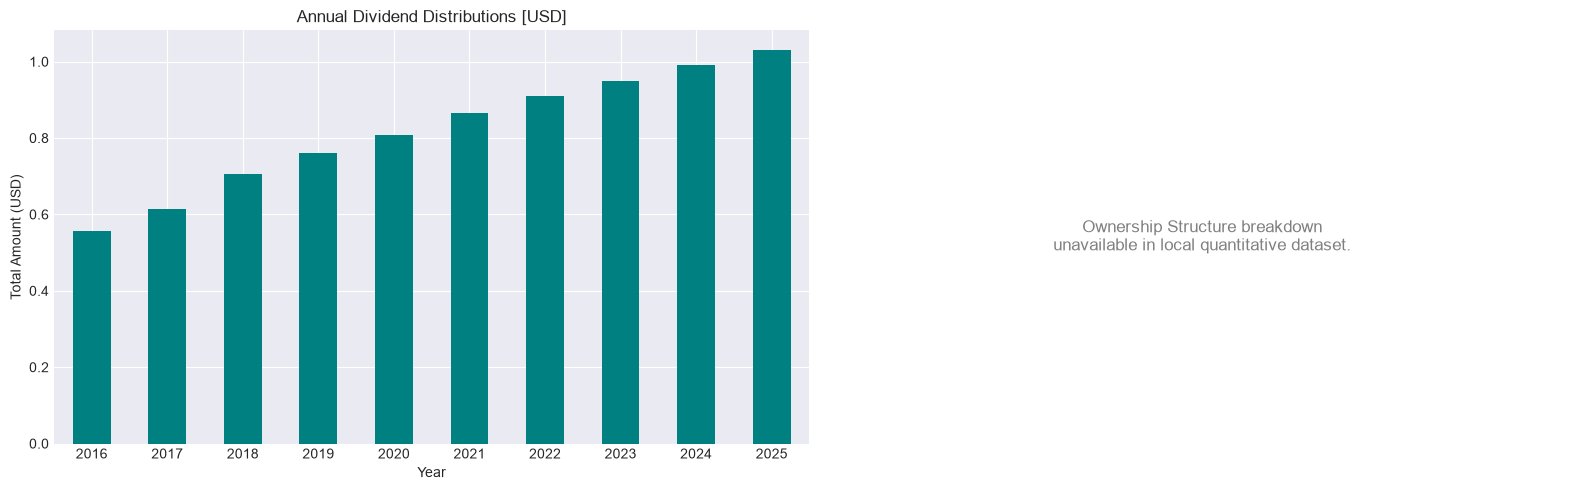

In [7]:
"""
Fetch dividend history and render it. Ownership data is not consistently available locally.
"""
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Aggregate dividend distributions by year based on local records
if 'Dividends' in df.columns and df['Dividends'].notna().any():
    div_series = df.groupby(df['Date'].dt.year)['Dividends'].sum()
    current_year = datetime.now().year
    div_series = div_series[div_series.index < current_year]
    
    if not div_series.empty:
        div_series.tail(10).plot(kind='bar', ax=ax[0], color='teal')
        ax[0].set_title(f"Annual Dividend Distributions [{currency}]")
        ax[0].set_xlabel("Year")
        ax[0].set_ylabel(f"Total Amount ({currency})")
        ax[0].tick_params(axis='x', rotation=0)
    else:
        ax[0].text(0.5, 0.5, 'No completed dividend years', ha='center', va='center')
else:
    ax[0].text(0.5, 0.5, 'No dividend history available in dataset', ha='center', va='center')

# Display unavailability notification for Ownership Structure
ax[1].axis('off')
ax[1].text(0.5, 0.5, 'Ownership Structure breakdown\nunavailable in local quantitative dataset.', 
           ha='center', va='center', fontsize=12, color='gray')

plt.tight_layout()
plt.show()

## 8. Automated Fundamental Health Scorecard

In [8]:
"""
Evaluate stock fundamentals against predefined thresholds and generate a health scorecard.
"""
def generate_scorecard(latest_data, df_history):
    score = 0
    max_score = 6
    checks = []

    # Check 1: Valuation (Trailing P/E)
    pe = latest_data.get('P/E Ratio')
    if pd.notna(pe) and 0 < pe < 25:
        score += 1
        checks.append(("Valuation: Trailing P/E < 25", "PASS", f"{pe:.2f}"))
    else:
        checks.append(("Valuation: Trailing P/E < 25", "FAIL / CAUTION", f"{pe:.2f}" if pd.notna(pe) else 'N/A'))

    # Check 2: Profitability (ROE)
    net_income = latest_data.get('Net Income')
    equity = latest_data.get('Stockholders Equity')
    roe = (net_income / equity) if pd.notna(net_income) and pd.notna(equity) and equity != 0 else None
    
    if roe and roe > 0.15:
        score += 1
        checks.append(("Profitability: ROE > 15%", "PASS", f"{roe*100:.2f}%"))
    else:
        checks.append(("Profitability: ROE > 15%", "FAIL", f"{roe*100:.2f}%" if pd.notna(roe) else 'N/A'))

    # Check 3: Liquidity (Current Ratio)
    curr_assets = latest_data.get('Current Assets')
    curr_liab = latest_data.get('Current Liabilities')
    cr = (curr_assets / curr_liab) if pd.notna(curr_assets) and pd.notna(curr_liab) and curr_liab != 0 else None
    
    if cr and cr >= 1.2:
        score += 1
        checks.append(("Liquidity: Current Ratio >= 1.2", "PASS", f"{cr:.2f}"))
    else:
        checks.append(("Liquidity: Current Ratio >= 1.2", "RISK", f"{cr:.2f}" if pd.notna(cr) else 'N/A'))

    # Check 4: Solvency (Debt / Equity)
    debt = latest_data.get('Long-Term Debt')
    dte = (debt / equity) if pd.notna(debt) and pd.notna(equity) and equity != 0 else None
    
    if dte is not None and dte < 1.0:
        score += 1
        checks.append(("Solvency: Debt/Equity < 100%", "PASS", f"{dte*100:.2f}%"))
    else:
        checks.append(("Solvency: Debt/Equity < 100%", "HIGH DEBT", f"{dte*100:.2f}%" if pd.notna(dte) else 'N/A'))

    # Check 5: Net Profit Margin
    revenue = latest_data.get('Revenue')
    margin = (net_income / revenue) if pd.notna(net_income) and pd.notna(revenue) and revenue != 0 else None
    
    if margin and margin > 0.10:
        score += 1
        checks.append(("Efficiency: Net Margin > 10%", "PASS", f"{margin*100:.2f}%"))
    else:
        checks.append(("Efficiency: Net Margin > 10%", "LOW MARGIN", f"{margin*100:.2f}%" if pd.notna(margin) else 'N/A'))

    # Check 6: Revenue Growth YoY
    # Approximately 252 trading days in a year
    if len(df_history) >= 252 and pd.notna(revenue):
        past_revenue = df_history.iloc[-252].get('Revenue')
        rev_growth = (revenue / past_revenue) - 1 if pd.notna(past_revenue) and past_revenue != 0 else None
    else:
        rev_growth = None
        
    if rev_growth and rev_growth > 0.05:
        score += 1
        checks.append(("Growth: Revenue Growth YoY > 5%", "PASS", f"{rev_growth*100:.2f}%"))
    else:
        checks.append(("Growth: Revenue Growth YoY > 5%", "SLOW / NEGATIVE", f"{rev_growth*100:.2f}%" if pd.notna(rev_growth) else 'N/A'))

    print(f"=== FUNDAMENTAL SCORECARD: {score}/{max_score} ===")
    return pd.DataFrame(checks, columns=['Criterion', 'Status', 'Actual Value'])

df_scorecard = generate_scorecard(latest_data, df)
df_scorecard.style.hide(axis="index").map(
    lambda v: 'background-color: #d4edda; color: #155724' if 'PASS' in str(v) else 'background-color: #f8d7da; color: #721c24',
    subset=['Status']
)

=== FUNDAMENTAL SCORECARD: 2/6 ===


Criterion,Status,Actual Value
Valuation: Trailing P/E < 25,FAIL / CAUTION,44.35
Profitability: ROE > 15%,PASS,275.21%
Liquidity: Current Ratio >= 1.2,RISK,0.99
Solvency: Debt/Equity < 100%,HIGH DEBT,153.32%
Efficiency: Net Margin > 10%,PASS,64.40%
Growth: Revenue Growth YoY > 5%,SLOW / NEGATIVE,0.00%
